In [ ]:
def date_prepocessing(df):
    # 1. Trabajamos sobre una copia para evitar conflictos de memoria
    df = df.copy()
    
    # 2. Limpieza radical de nombres y filas vacías
    df.columns = df.columns.str.strip()
    df = df.dropna(how='all') # Elimina filas totalmente vacías
    
    # 3. Búsqueda flexible de la columna de tiempo
    col_timestamp = [c for c in df.columns if 'timestamp' in c.lower()]
    
    if not col_timestamp:
        raise KeyError(f"No encontré 'timestamp'. Columnas: {list(df.columns)}")
    
    # 4. Conversión flexible (sin forzar un formato rígido)
    # dayfirst=True es vital si tus fechas son tipo 31.12.2023
    df["Date and time"] = pd.to_datetime(df[col_timestamp[0]], dayfirst=True, errors='coerce')
    
    # Eliminamos filas donde la fecha no se pudo convertir
    df = df.dropna(subset=["Date and time"])
    
    df = df.set_index("Date and time")
    
    # 5. Limpieza de columnas sobrantes
    df.drop(columns=["meter_Empresa I1_raw", col_timestamp[0]], errors='ignore', inplace=True)

    # 6. Reindexado e Interpolación
    # Aseguramos que el índice sea DatetimeIndex
    rango_horario_completo = pd.date_range(start=df.index.min(), end=df.index.max(), freq="15min")
    df = df.reindex(rango_horario_completo)
    df = df.interpolate(method="linear")
    
    df.index.name = "DATETIME"
    
    # 7. Renombrar la columna objetivo
    col_target = [c for c in df.columns if 'meter_Empresa I1' in c.lower()]
    if col_target:
        df['PLANT CONSUMPTION (KWh)'] = df[col_target[0]]
        if col_target[0] != 'PLANT CONSUMPTION (KWh)':
            df.drop(columns=[col_target[0]], inplace=True)


    columna_objetivo = 'PLANT CONSUMPTION (KWh)'

    # 3. Reemplazar negativos por 0
    df[columna_objetivo] = df[columna_objetivo].apply(lambda x: x if x >= 0 else 0)
    
    return df

# Intenta ejecutarlo ahora
df = date_prepocessing(df[2:])
print(df)

                     PLANT CONSUMPTION (KWh)
DATETIME                                    
2022-04-20 16:15:00                 25.57577
2022-04-20 16:30:00                 18.78690
2022-04-20 16:45:00                 20.47515
2022-04-20 17:00:00                 25.03434
2022-04-20 17:15:00                 20.71976
...                                      ...
2023-04-23 10:45:00                 21.27928
2023-04-23 11:00:00                 20.81361
2023-04-23 11:15:00                 20.02094
2023-04-23 11:30:00                 20.15965
2023-04-23 11:45:00                 19.43264

[35311 rows x 1 columns]


C:\Users\andy0\AppData\Local\Temp\ipykernel_4960\1093347080.py:17: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["Date and time"] = pd.to_datetime(df[col_timestamp[0]], dayfirst=True, errors='coerce')


In [ ]:

def time_features(df):
    minutos_dia = df.index.hour * 60 
    periodo = 24 * 60
    df["hora_sin"] = np.sin(2 * np.pi * minutos_dia / periodo)
    df["hora_cos"] = np.cos(2 * np.pi * minutos_dia / periodo)
    df["dia_semana"] = df.index.dayofweek

    return df

df = time_features(df)


In [ ]:
import numpy as np
import pandas as pd


# =============================================================================
# CONFIGURACIÓN
# =============================================================================

# Columna donde se modificarán los valores
TARGET_COLUMN = "PLANT CONSUMPTION (KWh)"

# División de los datos:
# 80 % entrenamiento, 10 % validación y 10 % test
TRAIN_SIZE = 0.80
VAL_SIZE = 0.10

# Porcentaje de anomalías que se insertará en el conjunto de test
# 0.005 equivale al 0.5 %
ANOMALY_PERCENTAGE = 0.003

# Un spike será 2.5 veces el máximo habitual
SPIKE_FACTOR = 2.5

# Un drop será el 10 % del mínimo habitual
DROP_FACTOR = 0.10

# Semilla para obtener siempre las mismas anomalías
RANDOM_SEED = 42

# Separación mínima entre anomalías
# 4 lecturas de 15 minutos equivalen a una hora
MIN_DISTANCE_READINGS = 100

# Como máximo, el 85 % de los días podrá contener anomalías
ANOMALY_DAY_FRACTION = 0.85

# Número de primeras lecturas del test que se reservan
# para formar la ventana temporal inicial del modelo
RESERVED_READINGS = 96


# =============================================================================
# COMPROBACIONES INICIALES
# =============================================================================

if not isinstance(df.index, pd.DatetimeIndex):
    raise TypeError(
        "El índice de df debe ser de tipo DatetimeIndex."
    )

if TARGET_COLUMN not in df.columns:
    raise KeyError(
        f"No existe la columna '{TARGET_COLUMN}'. "
        f"Columnas disponibles: {df.columns.tolist()}"
    )

# Evitar ejecutar dos veces la inserción de anomalías
if (
    "is_anomaly" in df.columns
    and df["is_anomaly"].eq(1).any()
):
    raise RuntimeError(
        "df ya contiene anomalías. "
        "Vuelve a cargar los datos originales antes de ejecutar esta celda."
    )


# =============================================================================
# ELIMINAR FECHAS DUPLICADAS
# =============================================================================

if df.index.has_duplicates:

    # Contar cuántas filas repetidas existen
    numero_duplicados = df.index.duplicated(
        keep="first"
    ).sum()

    print(
        f"Se encontraron {numero_duplicados} fechas duplicadas."
    )

    # Asegurar que el índice tiene un nombre
    if df.index.name is None:
        df.index.name = "datetime"

    nombre_indice = df.index.name

    # Pasar temporalmente la fecha a una columna
    df.reset_index(inplace=True)

    # Conservar solamente la primera fila de cada fecha
    df.drop_duplicates(
        subset=[nombre_indice],
        keep="first",
        inplace=True
    )

    # Volver a colocar la fecha como índice
    df.set_index(
        nombre_indice,
        inplace=True
    )

    print(
        "Se conservó la primera lectura de cada fecha."
    )


# Ordenar cronológicamente
df.sort_index(inplace=True)

df[TARGET_COLUMN] = pd.to_numeric(
    df[TARGET_COLUMN],
    errors="coerce"
)


df["is_anomaly"] = 0
df["anomaly_type"] = "none"


# =============================================================================
# =============================================================================

numero_total_datos = len(df)

numero_train = int(
    TRAIN_SIZE * numero_total_datos
)

numero_validacion = int(
    VAL_SIZE * numero_total_datos
)

inicio_test = numero_train + numero_validacion

test = df.iloc[inicio_test:]

if test.empty:
    raise ValueError(
        "El conjunto de test está vacío."
    )

if len(test) <= RESERVED_READINGS:
    raise ValueError(
        "El conjunto de test no contiene suficientes registros "
        "después de reservar las primeras 96 lecturas."
    )

valid_test = test[
    [TARGET_COLUMN]
].dropna().copy()

if valid_test.empty:
    raise ValueError(
        "El conjunto de test no contiene valores válidos."
    )


# =============================================================================
# CREAR INFORMACIÓN TEMPORAL
# =============================================================================


valid_test["_weekday"] = (
    valid_test.index.dayofweek
)


valid_test["_reading_time"] = (
    valid_test.index.time
)


# =============================================================================
# =============================================================================


groups = valid_test.groupby(
    ["_weekday", "_reading_time"],
    sort=False
)

group_values = groups[TARGET_COLUMN].agg(
    max_value="max",
    min_value="min"
)

group_values["max_timestamp"] = (
    groups[TARGET_COLUMN].idxmax()
)

group_values["min_timestamp"] = (
    groups[TARGET_COLUMN].idxmin()
)

group_values["group_size"] = (
    groups[TARGET_COLUMN].size()
)

group_values = group_values[
    group_values["group_size"] >= 2
]

if group_values.empty:
    raise ValueError(
        "No existen suficientes lecturas repetidas "
        "por día de la semana y momento de lectura."
    )

valid_test = valid_test.join(
    group_values,
    on=["_weekday", "_reading_time"],
    how="inner"
)


# =============================================================================
# CALCULAR EL NÚMERO DE ANOMALÍAS
# =============================================================================

numero_anomalias = int(
    round(
        len(test) * ANOMALY_PERCENTAGE
    )
)


if numero_anomalias % 2 != 0:
    numero_anomalias -= 1

if numero_anomalias < 2:
    raise ValueError(
        "El conjunto de test es demasiado pequeño "
        "para insertar anomalías."
    )

numero_spikes = numero_anomalias // 2
numero_drops = numero_anomalias // 2


# =============================================================================
# SELECCIONAR LOS DÍAS CON ANOMALÍAS
# =============================================================================

dias_disponibles = pd.DatetimeIndex(
    valid_test.index.normalize().unique()
)

numero_dias_seleccionados = int(
    np.ceil(
        len(dias_disponibles)
        * ANOMALY_DAY_FRACTION
    )
)

# Dejar al menos un día sin anomalías
numero_dias_seleccionados = min(
    numero_dias_seleccionados,
    len(dias_disponibles) - 1
)

numero_dias_seleccionados = max(
    numero_dias_seleccionados,
    1
)


# =============================================================================
# FECHAS RESERVADAS PARA LA VENTANA TEMPORAL
# =============================================================================


fechas_reservadas = set(
    test.index[:RESERVED_READINGS]
)


# =============================================================================
# SELECCIONAR LAS FECHAS DE LAS ANOMALÍAS
# =============================================================================


posiciones_test = {
    fecha: posicion
    for posicion, fecha in enumerate(test.index)
}

spikes_seleccionados = []
drops_seleccionados = []

seleccion_completada = False


# Se realizan varios intentos para encontrar posiciones válidas
for intento in range(200):

    rng = np.random.default_rng(
        RANDOM_SEED + intento
    )

    # Elegir los días que podrán contener anomalías
    dias_seleccionados = pd.DatetimeIndex(
        rng.choice(
            np.asarray(
                dias_disponibles,
                dtype="datetime64[ns]"
            ),
            size=numero_dias_seleccionados,
            replace=False
        )
    )

    # Seleccionar las lecturas de los días elegidos
    candidatos = valid_test[
        valid_test.index.normalize().isin(
            dias_seleccionados
        )
    ]

    # Un spike no se coloca donde ya estaba el máximo
    candidatos_spike = candidatos[
        candidatos.index
        != candidatos["max_timestamp"]
    ].index.to_list()

    # Un drop no se coloca donde ya estaba el mínimo
    candidatos_drop = candidatos[
        candidatos.index
        != candidatos["min_timestamp"]
    ].index.to_list()



    rng.shuffle(candidatos_spike)
    rng.shuffle(candidatos_drop)

    # Eliminar después del shuffle las fechas reservadas
    candidatos_spike = [
        fecha
        for fecha in candidatos_spike
        if fecha not in fechas_reservadas
    ]

    candidatos_drop = [
        fecha
        for fecha in candidatos_drop
        if fecha not in fechas_reservadas
    ]

    spikes_seleccionados = []
    drops_seleccionados = []

    posiciones_seleccionadas = set()
    posiciones_por_dia = {}

    puntero_spike = 0
    puntero_drop = 0


    def posicion_valida(fecha):
        """
        Comprueba que la fecha no esté seleccionada
        y que esté suficientemente separada de otras anomalías.
        """

        posicion = posiciones_test[fecha]
        dia = fecha.normalize()

        # No seleccionar dos veces la misma posición
        if posicion in posiciones_seleccionadas:
            return False


        if fecha in fechas_reservadas:
            return False


        for posicion_anterior in posiciones_por_dia.get(
            dia,
            []
        ):
            if (
                abs(posicion - posicion_anterior)
                < MIN_DISTANCE_READINGS
            ):
                return False

        return True


    def guardar_posicion(fecha):
        """
        Guarda la posición de una anomalía seleccionada.
        """

        posicion = posiciones_test[fecha]
        dia = fecha.normalize()

        posiciones_seleccionadas.add(
            posicion
        )

        posiciones_por_dia.setdefault(
            dia,
            []
        ).append(
            posicion
        )


    # Alternar la selección de spikes y drops
    while (
        len(spikes_seleccionados) < numero_spikes
        or len(drops_seleccionados) < numero_drops
    ):

        hubo_progreso = False

        # ---------------------------------------------------------------------
        # Seleccionar un spike
        # ---------------------------------------------------------------------

        if len(spikes_seleccionados) < numero_spikes:

            while puntero_spike < len(candidatos_spike):

                fecha = candidatos_spike[
                    puntero_spike
                ]

                puntero_spike += 1

                if posicion_valida(fecha):

                    spikes_seleccionados.append(
                        fecha
                    )

                    guardar_posicion(
                        fecha
                    )

                    hubo_progreso = True

                    break


        # ---------------------------------------------------------------------
        # Seleccionar un drop
        # ---------------------------------------------------------------------

        if len(drops_seleccionados) < numero_drops:

            while puntero_drop < len(candidatos_drop):

                fecha = candidatos_drop[
                    puntero_drop
                ]

                puntero_drop += 1

                if posicion_valida(fecha):

                    drops_seleccionados.append(
                        fecha
                    )

                    guardar_posicion(
                        fecha
                    )

                    hubo_progreso = True

                    break


        # Salir si ya no se encuentran posiciones válidas
        if not hubo_progreso:
            break


    # Comprobar si se encontraron todas las anomalías
    if (
        len(spikes_seleccionados) == numero_spikes
        and len(drops_seleccionados) == numero_drops
    ):
        seleccion_completada = True
        break


if not seleccion_completada:
    raise ValueError(
        "No fue posible insertar todas las anomalías "
        "respetando las restricciones establecidas."
    )


# =============================================================================
# INSERTAR LOS SPIKES
# =============================================================================

for fecha in spikes_seleccionados:

    # Obtener el máximo habitual para ese día de la semana
    # y momento exacto de lectura
    maximo_habitual = valid_test.at[
        fecha,
        "max_value"
    ]

    # Crear el valor anómalo
    valor_spike = (
        maximo_habitual
        * SPIKE_FACTOR
    )

    # Sustituir el consumo original por el valor anómalo
    df.at[
        fecha,
        TARGET_COLUMN
    ] = valor_spike

    # Marcar esa fecha como anomalía
    df.at[
        fecha,
        "is_anomaly"
    ] = 1

    # Guardar el tipo de anomalía
    df.at[
        fecha,
        "anomaly_type"
    ] = "spike"


# =============================================================================
# INSERTAR LOS DROPS
# =============================================================================

for fecha in drops_seleccionados:

    # Obtener el mínimo habitual para ese día de la semana
    # y momento exacto de lectura
    minimo_habitual = valid_test.at[
        fecha,
        "min_value"
    ]

    # Crear el valor anómalo
    valor_drop = (
        minimo_habitual
        * DROP_FACTOR
    )

    # Sustituir el consumo original por el valor anómalo
    df.at[
        fecha,
        TARGET_COLUMN
    ] = valor_drop

    # Marcar esa fecha como anomalía
    df.at[
        fecha,
        "is_anomaly"
    ] = 1

    # Guardar el tipo de anomalía
    df.at[
        fecha,
        "anomaly_type"
    ] = "drop"


# =============================================================================
# =============================================================================


anomaly = df[
    "anomaly_type"
].copy()


# =============================================================================
# MOSTRAR EL RESULTADO
# =============================================================================

fechas_anomalas = (
    spikes_seleccionados
    + drops_seleccionados
)

dias_con_anomalias = pd.DatetimeIndex(
    fechas_anomalas
).normalize().unique()


print("Proceso terminado correctamente.")
print()

print(
    f"Registros totales: "
    f"{len(df)}"
)

print(
    f"Registros del test: "
    f"{len(test)}"
)

print(
    f"Primeros registros reservados: "
    f"{RESERVED_READINGS}"
)

print(
    f"Anomalías insertadas: "
    f"{numero_anomalias}"
)

print(
    f"Spikes insertados: "
    f"{len(spikes_seleccionados)}"
)

print(
    f"Drops insertados: "
    f"{len(drops_seleccionados)}"
)

print(
    f"Porcentaje de anomalías en el test: "
    f"{numero_anomalias / len(test) * 100:.2f} %"
)

print(
    f"Días con anomalías: "
    f"{len(dias_con_anomalias)} de "
    f"{len(dias_disponibles)}"
)


# =============================================================================
# =============================================================================

anomalias_primeras_96 = df.loc[
    test.index[:RESERVED_READINGS],
    "is_anomaly"
].sum()

print()

print(
    f"Anomalías en las primeras "
    f"{RESERVED_READINGS} lecturas: "
    f"{anomalias_primeras_96}"
)


# =============================================================================
# MOSTRAR LAS PRIMERAS ANOMALÍAS INSERTADAS
# =============================================================================

print()
print(
    "Primeras anomalías insertadas:"
)

print(
    df.loc[
        df["is_anomaly"] == 1,
        [
            TARGET_COLUMN,
            "is_anomaly",
            "anomaly_type"
        ]
    ].head(10)
)

df.drop(
    columns=["anomaly_type"],
    inplace=True
)

Proceso terminado correctamente.

Registros totales: 35311
Registros del test: 3532
Primeros registros reservados: 96
Anomalías insertadas: 10
Spikes insertados: 5
Drops insertados: 5
Porcentaje de anomalías en el test: 0.28 %
Días con anomalías: 10 de 38

Anomalías en las primeras 96 lecturas: 0

Primeras anomalías insertadas:
                     PLANT CONSUMPTION (KWh)  is_anomaly anomaly_type
DATETIME                                                             
2023-03-21 16:00:00                86.341800           1        spike
2023-03-25 01:45:00                 0.096325           1         drop
2023-03-26 17:15:00                58.207700           1        spike
2023-03-29 18:30:00                 0.122453           1         drop
2023-04-08 13:45:00                69.141200           1        spike
2023-04-09 10:45:00                65.086175           1        spike
2023-04-15 10:15:00                 1.894812           1         drop
2023-04-17 07:30:00                 2.35

In [6]:
def stadistical_features(df):
    df["mean_1h"] = df["PLANT CONSUMPTION (KWh)"].rolling("1h").mean().shift(1)
    df["mean_6h"] = df["PLANT CONSUMPTION (KWh)"].rolling("6h").mean().shift(1)
    df["mean_12h"] = df["PLANT CONSUMPTION (KWh)"].rolling("12h").mean().shift(1)
    df["mean_24h"] = df["PLANT CONSUMPTION (KWh)"].rolling("24h").mean().shift(1)
    df['is_on'] = (df['PLANT CONSUMPTION (KWh)'].shift(1) > 5).astype(int)
    df["std_1h"] = df["PLANT CONSUMPTION (KWh)"].rolling(4).std().shift(1)
    df["dy_1"] = df["PLANT CONSUMPTION (KWh)"].diff().shift(1)
    df['dy_2'] = df['PLANT CONSUMPTION (KWh)'].diff(2).shift(1)
    df["v_672"] = df["PLANT CONSUMPTION (KWh)"].shift(24*7).fillna(df["PLANT CONSUMPTION (KWh)"])
    df = df.dropna().copy()
    return df

df_stat = stadistical_features(df)
df_stat.head()

,PLANT CONSUMPTION (KWh),hora_sin,hora_cos,dia_semana,is_anomaly,mean_1h,mean_6h,mean_12h,mean_24h,is_on,std_1h,dy_1,dy_2,v_672
DATETIME,,,,,,,,,,,,,,
2022-04-20 17:15:00,20.71976,-0.965926,-2.588190e-01,2,0,22.468040,22.468040,22.468040,22.468040,1,3.354911,4.55919,6.24744,20.71976
2022-04-20 17:30:00,20.36010,-0.965926,-2.588190e-01,2,0,21.254038,22.118384,22.118384,22.118384,1,2.662679,-4.31458,0.24461,20.36010
2022-04-20 17:45:00,24.61732,-0.965926,-2.588190e-01,2,0,21.647337,21.825337,21.825337,21.825337,1,2.262977,-0.35966,-4.67424,24.61732
2022-04-20 18:00:00,22.94526,-1.000000,-1.836970e-16,2,0,22.682880,22.224191,22.224191,22.224191,1,2.484658,4.25722,3.89756,22.94526
2022-04-20 18:15:00,22.53286,-1.000000,-1.836970e-16,2,0,22.160610,22.314325,22.314325,22.314325,1,1.997414,-1.67206,2.58516,22.53286


In [7]:
def divide_data(df, train_size=0.8, val_size=0.2):
    N = df.shape[0]
    Ntrain = int(train_size * N)  #Número de datos de entrenamiento
    Nval = int(val_size * N)      #Número de datos de validación
    train = df[0:Ntrain]
    val = df[Ntrain : Ntrain + Nval]
    test = df[Ntrain + Nval :]
    return train, val, test

train,val,test = divide_data(df_stat,train_size=0.8, val_size=0.1)
print(f'Tamaño set de entrenamiento: {train.shape}')
print(f'Tamaño set de validación: {val.shape}')
print(f'Tamaño set de prueba: {test.shape}')

Tamaño set de entrenamiento: (28245, 14)
Tamaño set de validación: (3530, 14)
Tamaño set de prueba: (3532, 14)


In [8]:
from sklearn.preprocessing import StandardScaler

def scale_data(train, val, test, target_col):
    scaler = StandardScaler()
    scaler.fit(train[[target_col]])
    tr_scaled = scaler.transform(train.values.reshape(-1, 1)).reshape(train.shape)
    val_scaled = scaler.transform(val.values.reshape(-1, 1)).reshape(val.shape)
    test_scaled = scaler.transform(test.values.reshape(-1, 1)).reshape(test.shape)
    
    return tr_scaled, val_scaled, test_scaled, scaler


cyclic_cols = ["hora_sin", "hora_cos", "dia_semana", "is_on","is_anomaly"]
train_cyclic = train[cyclic_cols].values
val_cyclic = val[cyclic_cols].values
test_cyclic = test[cyclic_cols].values

tr_scaled, val_scaled, test_scaled, scaler = scale_data(train.drop(columns=cyclic_cols), val.drop(columns=cyclic_cols), test.drop(columns=cyclic_cols), "PLANT CONSUMPTION (KWh)")
X_train_scaled = np.concatenate([tr_scaled, train_cyclic], axis=1)
X_val_scaled = np.concatenate([val_scaled, val_cyclic], axis=1)
X_test_scaled = np.concatenate([test_scaled, test_cyclic], axis=1)

c:\Users\andy0\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\andy0\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\andy0\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [10]:
def window(array, input_length, output_length):
    # Inicialización
    X, Y = [], []
    fils, cols = array.shape 
    for i in range(fils-input_length-output_length):
        X.append(array[i:i+input_length,0:1])
        Y.append(array[i+input_length:i+input_length+output_length,0].reshape(output_length,1))
    X = np.array(X)
    Y = np.array(Y)

    return X, Y

X_train_temporal, y_tr= window(X_train_scaled , input_length=96, output_length=1)  
X_val_temporal, y_vl= window(X_val_scaled , input_length=96, output_length=1)
X_test_temporal, y_ts= window(X_test_scaled , input_length=96, output_length=1)

In [11]:
X_train_stat = X_train_scaled[95:-2, 1:-1]
X_val_stat   = X_val_scaled[95:-2, 1:-1]
X_test_stat  = X_test_scaled[95:-2, 1:-1]

In [12]:
y_ts1=y_ts.copy()
X_test_temporal1 = X_test_temporal.copy()
X_test_stat1 = X_test_stat.copy() 

In [13]:
# from tensorflow import keras
# from keras.models import Sequential,Model
# from keras.layers import Dense, LSTM, Dropout, RepeatVector, TimeDistributed, Input, Concatenate, Conv1D, MaxPooling1D, Flatten, Bidirectional
# from tensorflow.keras.callbacks import EarlyStopping

# def BiLSTM_Hybrid(X_train_temporal, X_train_stat, y_train, X_val_temporal, X_val_stat, y_val):
#     act_func = 'tanh'
#     n_feature      = int(X_train_temporal.shape[2])
#     n_time_steps   = int(X_train_temporal.shape[1])
#     n_feature_stat = int(X_train_stat.shape[1])

#     # --- Rama BiLSTM ---
#     input_temporal = Input(shape=(n_time_steps, n_feature))
#     x = Bidirectional(LSTM(n_time_steps, activation=act_func, return_sequences=True))(input_temporal)
#     x = Bidirectional(LSTM(n_time_steps, activation=act_func, return_sequences=False))(x)
#     input_stat = Input(shape=(n_feature_stat,))
#     y = Dense(64, activation='relu')(input_stat)
#     y = Dense(32, activation='relu')(y)
#     combined = Concatenate()([x, y])
#     output = Dense(1, activation='linear')(combined)
#     model = Model(inputs=[input_temporal, input_stat], outputs=output)
#     model.compile(optimizer='adam', loss='mse')
#     history = model.fit(
#         [X_train_temporal, X_train_stat],
#         y_train,
#         validation_data=(
#             [X_val_temporal, X_val_stat],
#             y_val
#         ),
#         epochs=50,
#         batch_size=32,
#         callbacks=[
#             EarlyStopping(patience=10, restore_best_weights=True)
#         ]
#     )
#     return model,history

# model_BiLSTM, history = BiLSTM_Hybrid(X_train_temporal, X_train_stat, y_tr, X_val_temporal, X_val_stat, y_vl)

In [ ]:
from tensorflow.keras.models import load_model

model_BiLSTM = load_model("C:\\Users\\andy0\\Documents\\Tesis\\02_Codes\\00_Codes_Consumption\\01_Models\\model_BiLSTM_Empresa I1.keras")

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred_scaled = model_BiLSTM.predict([X_test_temporal, X_test_stat])
y_pred = scaler.inverse_transform(y_pred_scaled)
y_test_real = scaler.inverse_transform(y_ts.reshape(-1, 1))

y_pred_val_scaled = model_BiLSTM.predict([X_val_temporal, X_val_stat])
y_pred_val = scaler.inverse_transform(y_pred_val_scaled)
y_val = scaler.inverse_transform(y_vl.reshape(-1, 1))

def eval_reg(y_true, y_pred, name):
    mse   = mean_squared_error(y_true, y_pred)
    rmse  = np.sqrt(mse)
    mae   = mean_absolute_error(y_true, y_pred)
    mape  = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    smape = np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred))) * 100
    r2    = r2_score(y_true, y_pred)

    print(f'{name}:')
    print(f'  MSE:   {mse:.3f}')
    print(f'  RMSE:  {rmse:.3f}')
    print(f'  MAE:   {mae:.3f}')
    print(f'  MAPE:  {mape:.2f}%')
    print(f'  SMAPE: {smape:.2f}%')
    print(f'  R²:    {r2:.4f}')
    print()

eval_reg(y_test_real, y_pred, 'TEST')
eval_reg(y_val, y_pred_val, 'VALIDATION')

108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step
TEST:
  MSE:   13.626
  RMSE:  3.691
  MAE:   1.901
  MAPE:  114.94%
  SMAPE: 32.24%
  R²:    0.9095

VALIDATION:
  MSE:   6.373
  RMSE:  2.524
  MAE:   1.455
  MAPE:  49.84%
  SMAPE: 30.61%
  R²:    0.9496



In [16]:
import numpy as np

def eval_reg(y_true, y_pred, name):
    mse   = mean_squared_error(y_true, y_pred)
    rmse  = np.sqrt(mse)
    mae   = mean_absolute_error(y_true, y_pred)
    mape  = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    smape = np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred))) * 100
    r2    = r2_score(y_true, y_pred)

    print(f'{name}:')
    print(f'  MSE:   {mse:.3f}')
    print(f'  RMSE:  {rmse:.3f}')
    print(f'  MAE:   {mae:.3f}')
    print(f'  MAPE:  {mape:.2f}%')
    print(f'  SMAPE: {smape:.2f}%')
    print(f'  R²:    {r2:.4f}')
    print()


eval_reg(y_val[1:], y_val[:-1], 'TEST')

TEST:
  MSE:   8.877
  RMSE:  2.979
  MAE:   1.588
  MAPE:  44.33%
  SMAPE: 28.32%
  R²:    0.9298



108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step


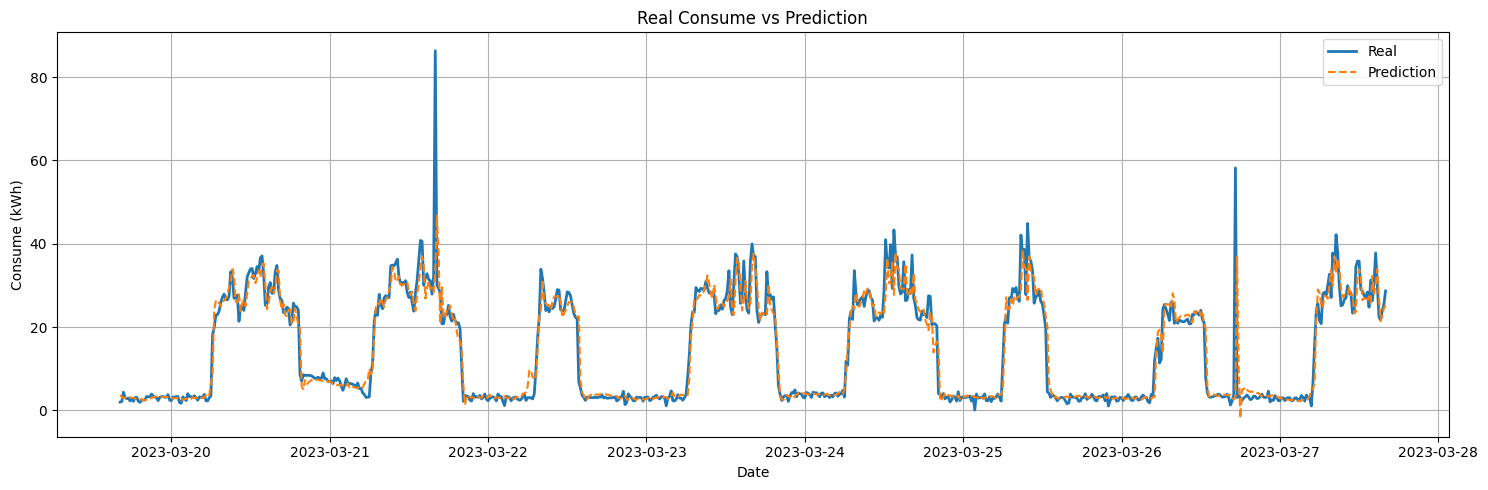

In [17]:
import matplotlib.pyplot as plt

def plot_window(ts, y_real, y_pred, start=130, n_dias=4, idx=1780):
    PTS_DIA = 96*2
    N = n_dias * PTS_DIA
    end = start + N
    x =50
    plt.figure(figsize=(15, 5))
    #plt.plot(ts.index[x:-97], y_real[x:], label='Real', linewidth=2)
    #plt.plot(ts.index[x:-97], y_pred[x:], label='Prediction', linestyle='--')
    plt.plot(ts.index[start+94+96:end+94+96], y_real[start+94:end+94], label='Real', linewidth=2)
    plt.plot(ts.index[start+94+96:end+94+96], y_pred[start+94:end+94], label='Prediction', linestyle='--')

    plt.title('Real Consume vs Prediction')
    plt.xlabel('Date')
    plt.ylabel('Consume (kWh)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show(block=True)

y_pred_scaled = model_BiLSTM.predict([X_test_temporal, X_test_stat])
y_pred = scaler.inverse_transform(y_pred_scaled)
y_test_real = scaler.inverse_transform(y_ts.reshape(-1, 1))
plot_window(test, y_test_real.flatten(), y_pred.flatten(), start=-1, n_dias=4, idx=1780)

108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step


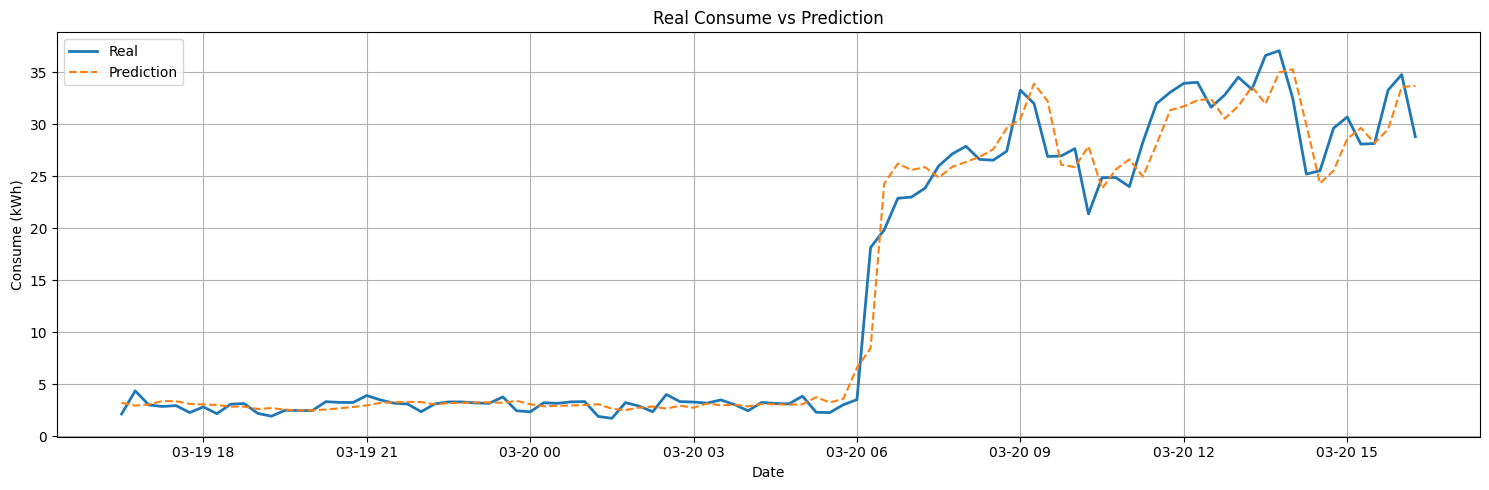

In [18]:
import matplotlib.pyplot as plt

def plot_window(ts, y_real, y_pred, start=130, n_dias=1, idx=1780):
    PTS_DIA = 96
    N = n_dias * PTS_DIA
    end = start + N

    plt.figure(figsize=(15, 5))
    plt.plot(ts.index[start+94+96:end+94+96], y_real[start+94:end+94], label='Real', linewidth=2)
    plt.plot(ts.index[start+94+96:end+94+96], y_pred[start+94:end+94], label='Prediction', linestyle='--')

    plt.title('Real Consume vs Prediction')
    plt.xlabel('Date')
    plt.ylabel('Consume (kWh)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show(block=True)

y_pred_scaled = model_BiLSTM.predict([X_test_temporal, X_test_stat])
y_pred = scaler.inverse_transform(y_pred_scaled)
y_test_real = scaler.inverse_transform(y_ts.reshape(-1, 1))
plot_window(test, y_test_real.flatten(), y_pred.flatten(), start=0, n_dias=1, idx=1780)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Predicción en escala normalizada
y_pred_scaled = model_BiLSTM.predict([X_test_temporal, X_test_stat])
y_pred_scaled_vl = model_BiLSTM.predict([X_val_temporal, X_val_stat])

# Desescalar
y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
y_pred = np.clip(y_pred, a_min=0, a_max=None)
y_real = scaler.inverse_transform(y_ts.reshape(-1, 1)).ravel()

y_pred_vl = scaler.inverse_transform(y_pred_scaled_vl.reshape(-1, 1)).ravel()
y_pred_vl = np.clip(y_pred_vl, a_min=0, a_max=None)
y_real_vl = scaler.inverse_transform(y_vl.reshape(-1, 1)).ravel()

# ── VAL ──────────────────────────────────────────────────────────────────────
df_vl = pd.DataFrame({
    'y_real': y_real_vl,
    'y_pred': y_pred_vl,
}, index=val[96:-1].index)

df_vl['quarter'] = df_vl.index.hour * 4 + df_vl.index.minute // 15
df_vl['error_kwh'] = np.abs(df_vl['y_real'] - df_vl['y_pred'])
df_vl['score_rel'] = df_vl['error_kwh'] / np.clip(df_vl['y_real'] + df_vl['y_pred'], a_min=1e-3, a_max=None)

P = 95
tau_by_context = df_vl.groupby('quarter')['score_rel'].quantile(P / 100)
df_vl['tau'] = df_vl['quarter'].map(tau_by_context)

# ── TEST ─────────────────────────────────────────────────────────────────────
df_test = pd.DataFrame({
    'y_real': y_real,
    'y_pred': y_pred,
}, index=test[96:-1].index)

df_test['quarter'] = df_test.index.hour * 4 + df_test.index.minute // 15
df_test['error_kwh'] = np.abs(df_test['y_real'] - df_test['y_pred'])
df_test['score_rel'] = df_test['error_kwh'] / np.clip(df_test['y_real'] + df_test['y_pred'], a_min=1e-3, a_max=None)
df_test['tau'] = df_test['quarter'].map(tau_by_context)

df_test['anomaly_strong'] = df_test['score_rel'] > (df_test['tau'] + 0.3)
df_test.loc[df_test['anomaly_strong'].shift(1).fillna(False), 'anomaly_strong'] = False
df_test['anomaly'] = df_test['score_rel'] > (df_test['tau'] + 0.1)

if df_test['anomaly_strong'].sum() > 0:
    print(f"Anomalías fuertes detectadas: {df_test['anomaly_strong'].sum()}")

# ── Anomaly type (solo sobre anomaly_strong) ──────────────────────────────────
df_test['anomaly_type_pred'] = 'none'
mask = df_test['anomaly_strong']
df_test.loc[mask & (df_test['y_real'] > df_test['y_pred']), 'anomaly_type_pred'] = 'spike'
df_test.loc[mask & (df_test['y_real'] < df_test['y_pred']), 'anomaly_type_pred'] = 'drop'


df_test['anomaly_final'] = df_test['anomaly_strong']

import json


threshold_data = {
    "tau_by_context": tau_by_context.to_dict(),  
    "horas": df_test.index.astype(str).tolist(),   
    "tau": df_test['tau'].tolist()                
}

with open("threshold_Empresa I1.json", "w") as f:
    json.dump(threshold_data, f, indent=2)

print("Threshold guardado en threshold_Empresa I1.json")

# ── Plot ──────────────────────────────────────────────────────────────────────
start = 0
end   = 300

fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(
    df_test.index[start:end],
    df_test['score_rel'].iloc[start:end],
    label='SMAPE (TEST)', color='steelblue', alpha=0.8
)
ax.plot(
    df_test.index[start:end],
    df_test['tau'].iloc[start:end],
    '--', label='Threshold', color='orange'
)

spikes = df_test.iloc[start:end][df_test['anomaly_type_pred'].iloc[start:end] == 'spike']
ax.scatter(spikes.index, spikes['score_rel'],
           color='red', marker='^', s=60, label='Spike (real > pred)', zorder=5)

drops = df_test.iloc[start:end][df_test['anomaly_type_pred'].iloc[start:end] == 'drop']
ax.scatter(drops.index, drops['score_rel'],
           color='purple', marker='v', s=60, label='Drop (real < pred)', zorder=5)

ax.set_title('TEST — SMAPE vs threshold | Spike vs Drop')
ax.set_xlabel('Date')
ax.set_ylabel('Threshold-SMAPE score')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
plt.show()

In [20]:
df_test['is_anomaly'] = df.loc[df_test.index, 'is_anomaly']
df_test['anomaly_type'] = anomaly.loc[df_test.index]
y_true = df_test['is_anomaly'].astype(int)
y_pred = df_test['anomaly_final'].astype(int)

In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print(cm)

[[3379   46]
 [   2    8]]


In [22]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      3425
           1       0.15      0.80      0.25        10

    accuracy                           0.99      3435
   macro avg       0.57      0.89      0.62      3435
weighted avg       1.00      0.99      0.99      3435



In [23]:
from sklearn.metrics import confusion_matrix

for t in ['spike', 'drop']:

    y_true = (df_test['anomaly_type']      == t).astype(int)  # etiquetas reales
    y_pred = (df_test['anomaly_type_pred'] == t).astype(int)  # etiquetas predichas

    print(f"\nTipo: {t}")
    print(confusion_matrix(y_true, y_pred))


Tipo: spike
[[3411   19]
 [   2    3]]

Tipo: drop
[[3403   27]
 [   0    5]]


In [ ]:
model_BiLSTM.save("model_BiLSTM_Empresa I1.keras")

c:\Users\andy0\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\andy0\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\andy0\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\andy0\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\andy0\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: U

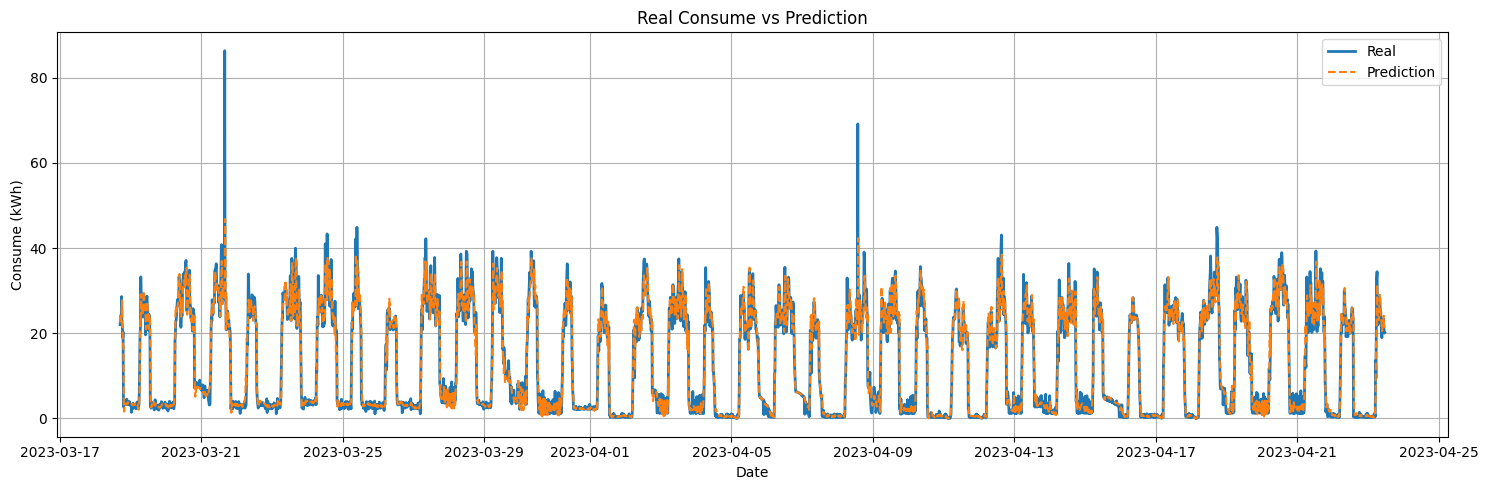

In [26]:
import keyboard

def esperar_tecla(tecla='any'):

    keyboard.wait(tecla)

def scale_data2(train, val, test, scaler):
    tr_scaled = scaler.transform(train.values.reshape(-1, 1)).reshape(train.shape)
    val_scaled = scaler.transform(val.values.reshape(-1, 1)).reshape(val.shape)
    test_scaled = scaler.transform(test.values.reshape(-1, 1)).reshape(test.shape)
    
    return tr_scaled, val_scaled, test_scaled

# ── Antes del bucle ──────────────────────────────────────────
scaler_original = scaler  # tau fue aprendido con este scaler
test_original = test.copy()  # Guarda el test original - NO debe cambiar
test_timestamps = test_original.index.tolist()  # Lista de timestamps para iterar

n_filas_train  = X_train_temporal.shape[0]
n_filas_val    = X_val_temporal.shape[0]
anomaly_streak = 0

list_anomalias = []
list_pred      = []
list_pred_timestamps = []
list_changes   = []
list_reg       = []
list_real      = []
list_anomaly_final = []
list_anomaly_presistent = []
list_anomaly_strong = []

# ── Bucle principal ──────────────────────────────────────────
for idx, timestamp in enumerate(test_timestamps[96:]):
    #esperar_tecla('enter')
    if timestamp not in test.index:
        continue
    current_pos = test.index.get_loc(timestamp)
    temporal_pos = current_pos - 96
    if temporal_pos < 0 or temporal_pos >= X_test_temporal.shape[0]:
        continue
    
    # 1. Prediccion -- siempre con scaler_original
    y_pred_scaled = model_BiLSTM.predict(
        [X_test_temporal[temporal_pos:temporal_pos+1], X_test_stat[temporal_pos:temporal_pos+1]], verbose=0
    )
    y_pred_val = float(scaler_original.inverse_transform(y_pred_scaled)[0][0])
    y_pred_val = max(y_pred_val, 0)
    list_pred.append(y_pred_val)
    list_pred_timestamps.append(timestamp)
    
    y_real_val = float(df.loc[timestamp, 'PLANT CONSUMPTION (KWh)'])
    #print(f"Timestamp: {timestamp} | Predicted: {y_pred_val:.3f} kWh | Real: {y_real_val:.3f} kWh")
    list_real.append(y_real_val)

    # 2. Score relativo
    quarter   = timestamp.hour * 4 + timestamp.minute // 15
    tau       = tau_by_context[quarter]
    score_rel = abs(y_real_val - y_pred_val) / max(y_real_val + y_pred_val, 1e-3)

    # 3. Deteccion
    anomaly_strong     = score_rel > (tau + 0.3)
    list_anomaly_strong.append(anomaly_strong)
    anomaly            = score_rel > (tau + 0.1)
    anomaly_streak     = anomaly_streak + 1 if anomaly else 0
    anomaly_persistent = anomaly_streak >= 3
    list_anomaly_presistent.append(anomaly_persistent)
    anomaly_final      = anomaly_strong or anomaly_persistent
    list_anomaly_final.append(anomaly_final)
    
    # 4. Correccion si hay anomalia
    if anomaly_final:
        valor_original = df.loc[timestamp, 'PLANT CONSUMPTION (KWh)']

        list_anomalias.append(timestamp)
        list_changes.append((valor_original, y_pred_val, y_real_val, score_rel, ))
        list_reg.append({
            'fecha'          : timestamp,
            'valor_original' : valor_original,
            'nuevo_valor'    : y_pred_val,
        })

        df.loc[timestamp, 'PLANT CONSUMPTION (KWh)'] = y_pred_val

        df_stat = stadistical_features(df)
        train, val, test = divide_data(df_stat, train_size=0.8, val_size=0.1)

        cyclic_cols  = ["hora_sin", "hora_cos", "dia_semana", "is_on", "is_anomaly"]
        train_cyclic = train[cyclic_cols].values
        val_cyclic   = val[cyclic_cols].values
        test_cyclic  = test[cyclic_cols].values

        tr_scaled, val_scaled, test_scaled = scale_data2(
            train.drop(columns=cyclic_cols),
            val.drop(columns=cyclic_cols),
            test.drop(columns=cyclic_cols),
            scaler_original
        )

        X_train_scaled = np.concatenate([tr_scaled, train_cyclic], axis=1)
        X_val_scaled   = np.concatenate([val_scaled, val_cyclic], axis=1)
        X_test_scaled  = np.concatenate([test_scaled, test_cyclic], axis=1)

        X_train_temporal, y_tr = window(X_train_scaled, input_length=96, output_length=1)
        X_val_temporal,   y_vl = window(X_val_scaled,   input_length=96, output_length=1)
        X_test_temporal,  y_ts = window(X_test_scaled,  input_length=96, output_length=1)

        X_train_stat = X_train_scaled[95:-2, 1:-1]
        X_val_stat   = X_val_scaled[95:-2, 1:-1]
        X_test_stat  = X_test_scaled[95:-2, 1:-1]

        n_filas_train = X_train_temporal.shape[0]
        n_filas_val   = X_val_temporal.shape[0]
        # ✅ scaler_original NO se actualiza nunca

# ── Plot ─────────────────────────────────────────────────────
import matplotlib.pyplot as plt

y_pred_all = np.array(list_pred)
pred_index = pd.Index(list_pred_timestamps)
y_test_real_all = df.loc[pred_index, 'PLANT CONSUMPTION (KWh)'].values

plt.figure(figsize=(15, 5))
plt.plot(pred_index, y_test_real_all, label='Real', linewidth=2)
plt.plot(pred_index, y_pred_all, label='Prediction', linestyle='--')
plt.title('Real Consume vs Prediction')
plt.xlabel('Date')
plt.ylabel('Consume (kWh)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show(block=True)

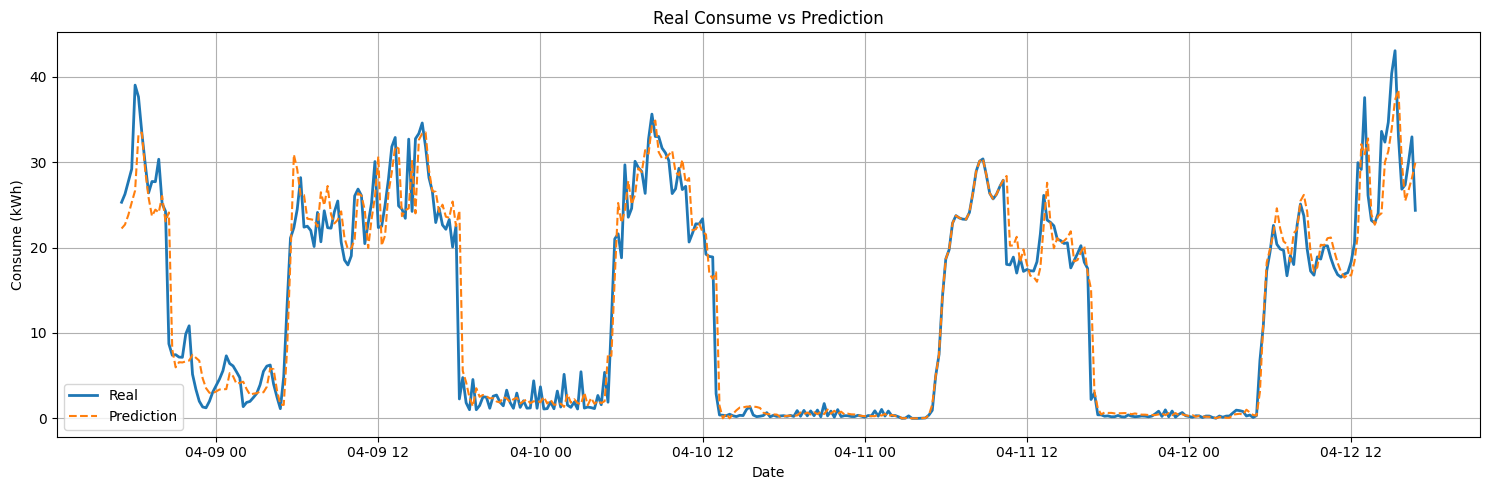

In [27]:
def plot_window(ts, y_real, y_pred, start=0, n_dias=4):
    PTS_DIA = 96  # ✅ 96 puntos/día si datos son cada 15 min
    N = n_dias * PTS_DIA
    end = start + N
    offset_ts = 96  # ventana temporal desplaza el índice de ts

    plt.figure(figsize=(15, 5))
    plt.plot(ts.index[start + offset_ts : end + offset_ts], 
             y_real[start:end], 
             label='Real', linewidth=2)
    plt.plot(ts.index[start + offset_ts : end + offset_ts], 
             y_pred[start:end], 
             label='Prediction', linestyle='--')

    plt.title('Real Consume vs Prediction')
    plt.xlabel('Date')
    plt.ylabel('Consume (kWh)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show(block=True)



y_pred_all      = np.array(list_pred)
y_test_real_all = scaler_original.inverse_transform(y_ts.reshape(-1, 1)).flatten()  # ✅ scaler_original
x = 19
plot_window(
    test,
    y_test_real_all,
    y_pred_all,
    start=192 +96 * x ,
    n_dias=4,
)

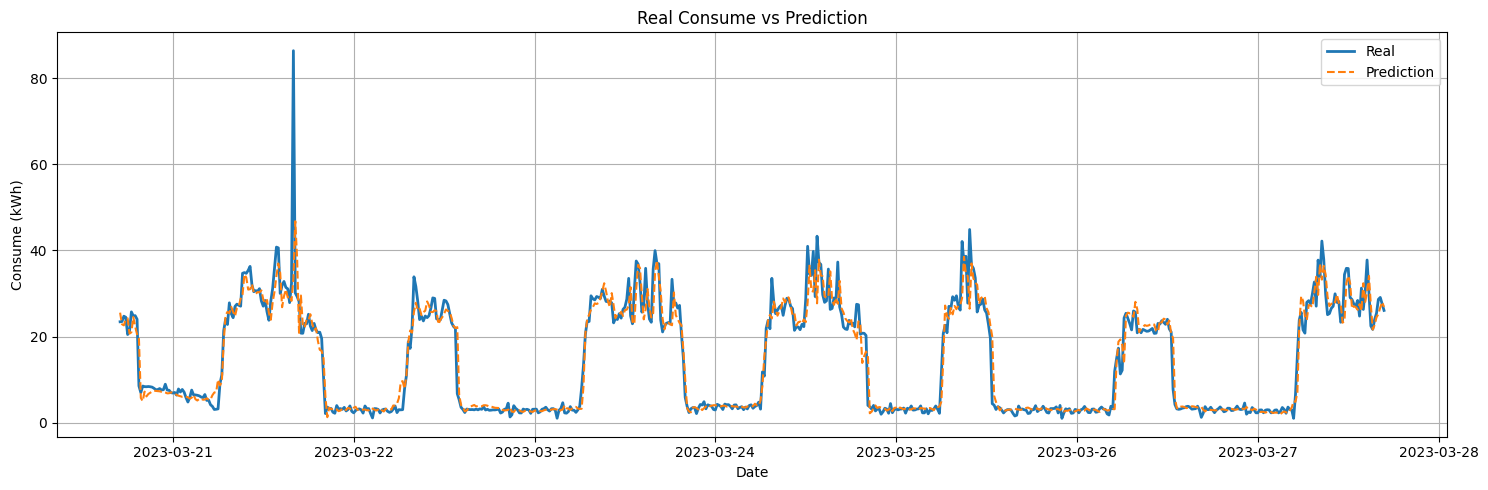

In [28]:
# ✅ list_pred ya contiene floats desescalados
y_pred_all = np.array(list_pred)  # shape: (n_samples,)
y_test_real_all = scaler.inverse_transform(y_ts.reshape(-1, 1)).flatten()

plot_window(
    test,
    y_test_real_all, 
    y_pred_all,
    start=192,
    n_dias=7,
)

In [29]:
eval_reg(y_test_real_all, y_pred_all, 'TEST')

TEST:
  MSE:   9.606
  RMSE:  3.099
  MAE:   1.713
  MAPE:  nan%
  SMAPE: nan%
  R²:    0.9341



C:\Users\andy0\AppData\Local\Temp\ipykernel_4960\1725284173.py:7: RuntimeWarning: invalid value encountered in divide
  mape  = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
C:\Users\andy0\AppData\Local\Temp\ipykernel_4960\1725284173.py:8: RuntimeWarning: invalid value encountered in divide
  smape = np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred))) * 100


In [30]:
eval_reg(y_test_real_all[1:], y_test_real_all[:-1], 'VAL - PREDICTED = REAL ANTERIOR')

VAL - PREDICTED = REAL ANTERIOR:
  MSE:   13.651
  RMSE:  3.695
  MAE:   1.976
  MAPE:  nan%
  SMAPE: nan%
  R²:    0.9064



C:\Users\andy0\AppData\Local\Temp\ipykernel_4960\1725284173.py:7: RuntimeWarning: divide by zero encountered in divide
  mape  = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
C:\Users\andy0\AppData\Local\Temp\ipykernel_4960\1725284173.py:7: RuntimeWarning: invalid value encountered in divide
  mape  = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
C:\Users\andy0\AppData\Local\Temp\ipykernel_4960\1725284173.py:8: RuntimeWarning: invalid value encountered in divide
  smape = np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred))) * 100


In [31]:
List_is_anomaly = df.loc[pred_index, 'is_anomaly'].values
cm = confusion_matrix(List_is_anomaly, list_anomaly_final)
print(cm)

[[3235  190]
 [   2    8]]


In [32]:
print(classification_report(List_is_anomaly, list_anomaly_final))

              precision    recall  f1-score   support

           0       1.00      0.94      0.97      3425
           1       0.04      0.80      0.08        10

    accuracy                           0.94      3435
   macro avg       0.52      0.87      0.52      3435
weighted avg       1.00      0.94      0.97      3435



In [33]:
from sklearn.metrics import confusion_matrix

for t in ['spike', 'drop']:
    
    y_true_type = (df_test['anomaly_type'] == t).astype(int)
    y_pred = list_anomaly_strong
    
    print(f"\nTipo: {t}")
    print(confusion_matrix(y_true_type, y_pred))


Tipo: spike
[[3273  157]
 [   2    3]]

Tipo: drop
[[3275  155]
 [   0    5]]



  TIPO: spike

✅ Verdadero Positivo (TP) — índice posicional 2087 (3 casos totales)


C:\Users\andy0\AppData\Local\Temp\ipykernel_4960\170483370.py:44: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\andy0\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


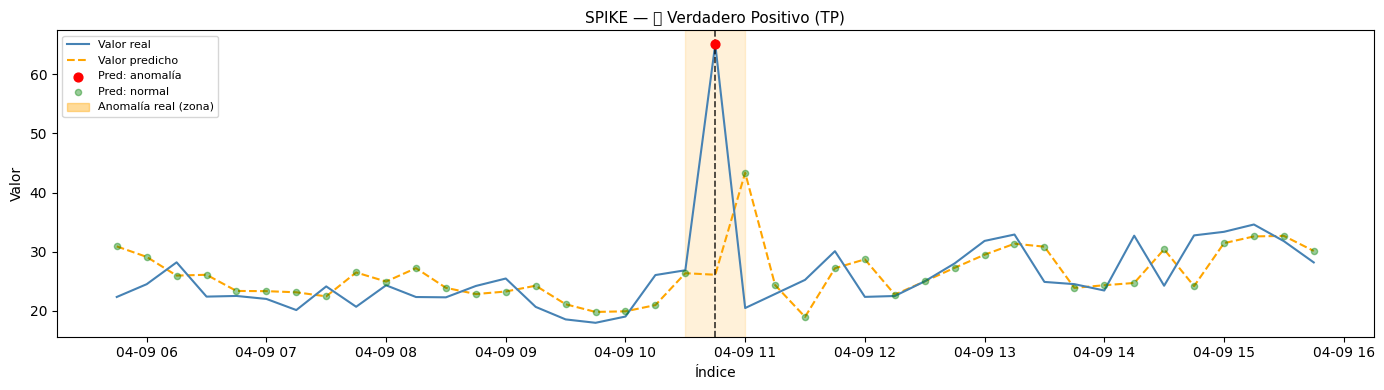


❌ Falso Positivo (FP) — índice posicional 2306 (19 casos totales)


C:\Users\andy0\AppData\Local\Temp\ipykernel_4960\170483370.py:44: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\andy0\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


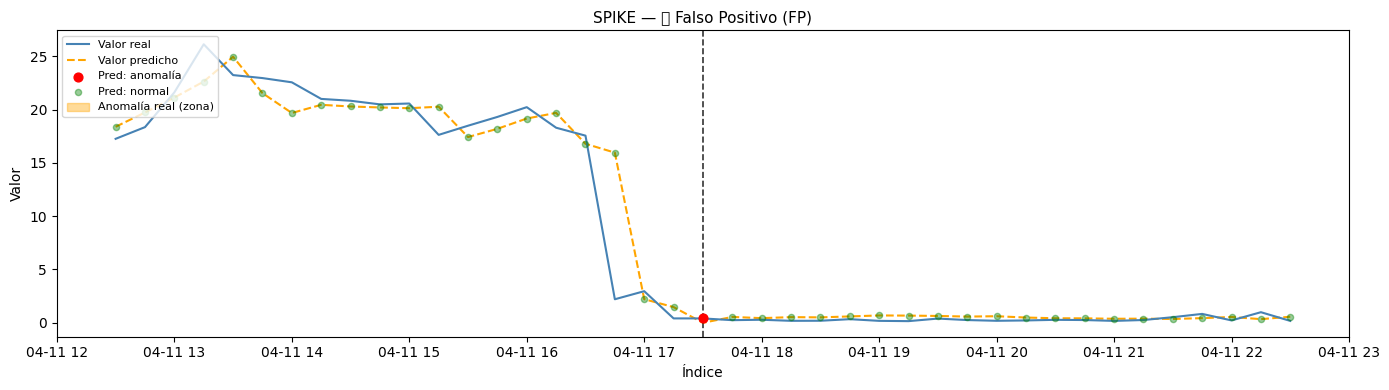


⚠️  Falso Negativo (FN) — índice posicional 2003 (2 casos totales)


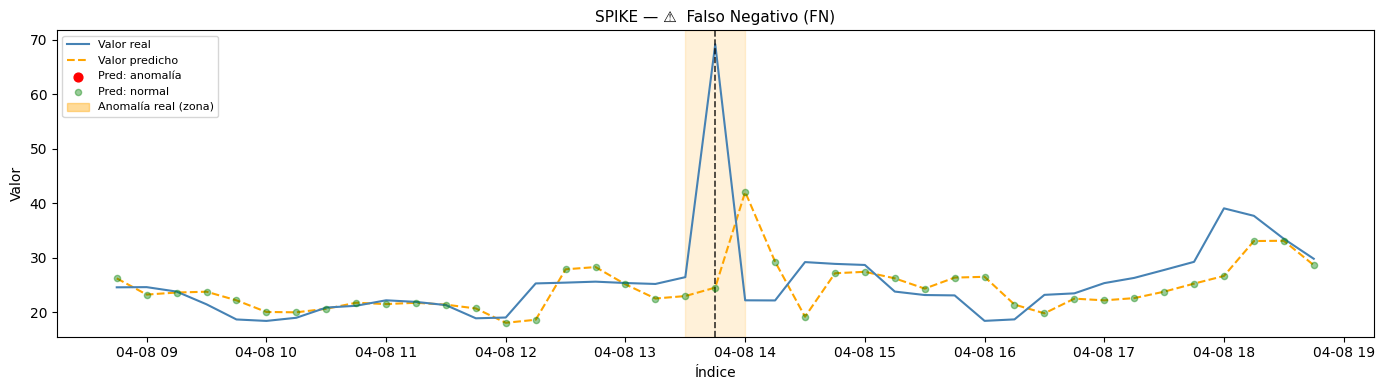


  TIPO: drop

✅ Verdadero Positivo (TP) — índice posicional 2661 (5 casos totales)


C:\Users\andy0\AppData\Local\Temp\ipykernel_4960\170483370.py:44: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\andy0\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


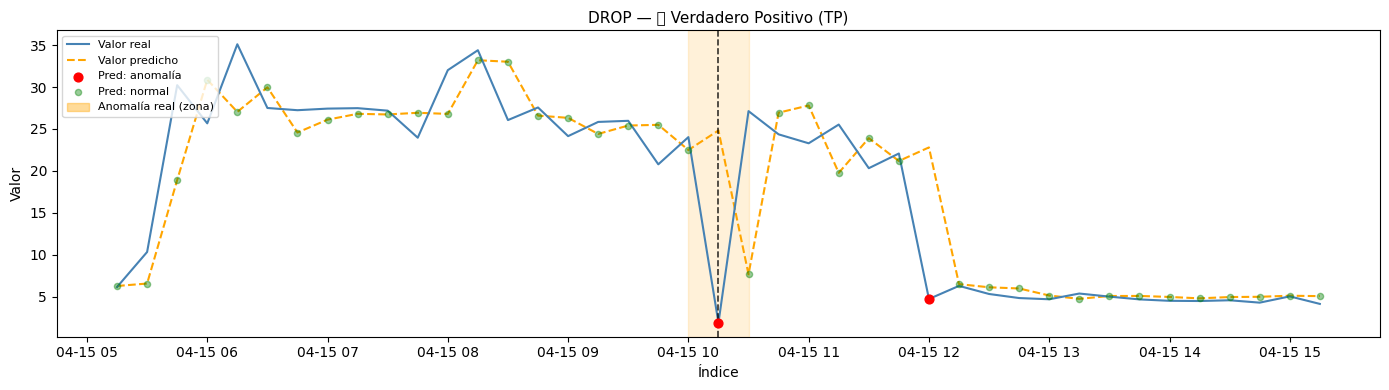


❌ Falso Positivo (FP) — índice posicional 2481 (27 casos totales)


C:\Users\andy0\AppData\Local\Temp\ipykernel_4960\170483370.py:44: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\andy0\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


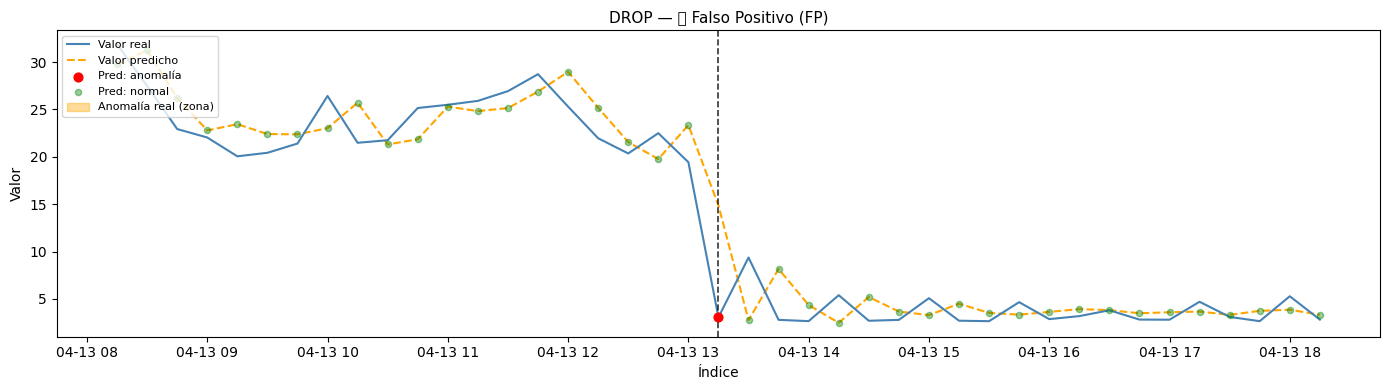


⚠️  Falso Negativo (FN): Sin ejemplos


In [34]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

case_types = ['spike', 'drop']

def plot_caso(df, idx, titulo="", ventana=20):
    start = max(0, idx - ventana)
    end   = min(len(df), idx + ventana + 1)
    subset = df.iloc[start:end]
    
    fig, ax = plt.subplots(figsize=(14, 4))
    
    ax.plot(subset.index, subset['y_real'], color='steelblue', linewidth=1.5, label='Valor real', zorder=3)
    ax.plot(subset.index, subset['y_pred'], color='orange', linestyle='--', label='Valor predicho', zorder=2)
    
    pred_pos = subset[subset['anomaly_strong'] == 1]
    pred_neg = subset[subset['anomaly_strong'] == 0]
    ax.scatter(pred_pos.index, pred_pos['y_real'], color='red',   s=40, zorder=5, label='Pred: anomalía')
    ax.scatter(pred_neg.index, pred_neg['y_pred'], color='green', s=20, zorder=5, label='Pred: normal', alpha=0.4)
    
    if hasattr(subset.index, 'freq') and subset.index.freq is not None:
        half_step = pd.tseries.frequencies.to_offset(subset.index.freq)
    else:
        diffs = pd.Series(subset.index).diff().dropna()
        half_step = diffs.median() / 2

    # Sombrea con anomaly_type (etiquetas REALES)
    for i in subset.index:
        if subset.loc[i, 'anomaly_type'] != 'none':
            ax.axvspan(i - half_step, i + half_step, alpha=0.15, color='orange', zorder=1)
    
    punto_x = df.index[idx]
    ax.axvline(x=punto_x, color='black', linestyle='--', linewidth=1.2, alpha=0.8, zorder=4)
    
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel("Índice")
    ax.set_ylabel("Valor")
    
    naranja = mpatches.Patch(color='orange', alpha=0.4, label='Anomalía real (zona)')
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles + [naranja], labels=labels + ['Anomalía real (zona)'], fontsize=8, loc='upper left')
    
    plt.tight_layout()
    plt.show()


for t in case_types:
    print(f"\n{'='*55}")
    print(f"  TIPO: {t}")
    print(f"{'='*55}")
    
    # anomaly_type      → etiquetas reales (a mano)
    # anomaly_type_pred → etiquetas predichas (modelo)
    y_true = (df_test['anomaly_type']      == t).astype(int)
    y_pred = (df_test['anomaly_type_pred'] == t).astype(int)
    
    masks = {
        '✅ Verdadero Positivo (TP)': (y_true == 1) & (y_pred == 1),
        '❌ Falso Positivo (FP)'    : (y_true == 0) & (y_pred == 1),
        '⚠️  Falso Negativo (FN)'   : (y_true == 1) & (y_pred == 0),
    }
    
    for label, mask in masks.items():
        indices_pos = np.where(mask)[0]
        
        if len(indices_pos) == 0:
            print(f"\n{label}: Sin ejemplos")
            continue
        
        idx_pos = indices_pos[len(indices_pos) // 2]
        print(f"\n{label} — índice posicional {idx_pos} ({len(indices_pos)} casos totales)")
        plot_caso(df_test, idx=idx_pos, titulo=f"{t.upper()} — {label}", ventana=20)

In [ ]:
import json
import pandas as pd
scaler = joblib.load("scaler_Empresa I1.pkl")
with open("threshold_Empresa I1.json") as f:
    threshold_data = json.load(f)

tau_by_context = pd.Series({int(k): v for k, v in threshold_data["tau_by_context"].items()})

# Reconstruir la serie completa de tau con su índice de fechas original
tau_series = pd.Series(
    threshold_data["tau"],
    index=pd.to_datetime(threshold_data["horas"])
)